# Multi-Touch Marketing Attribution Analysis

**Objective:** Compare three attribution models — Last Click, Linear, and Time Decay — to understand which channels are over- or under-credited under the default last-click model, and quantify the budget reallocation opportunity.

**Dataset:** ~15,000 touchpoints across 5,000 sessions (Jan–Sep 2024)  
**Models:** Last Click · Linear · Time Decay (λ=7 days)

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

df = pd.read_csv('data/touchpoints.csv', parse_dates=['session_date'])
print(f'Loaded {len(df):,} touchpoints | {df["session_id"].nunique():,} sessions')
print(f'Conversions: {df[df["converted"]==1]["session_id"].nunique():,}')
df.head()

Loaded 17,452 touchpoints | 5,000 sessions
Conversions: 768


,session_id,user_id,session_date,channel,touch_position,total_touches,converted,revenue,cost
0,1,828,2024-04-12,organic_search,1,4,0,0,0
1,1,828,2024-04-12,facebook_ads,2,4,0,0,8
2,1,828,2024-04-12,google_ads,3,4,0,0,12
3,1,828,2024-04-12,google_ads,4,4,0,0,12
4,2,1088,2024-02-15,direct,1,6,0,0,0


## 1. Last-Click Attribution

In [2]:
# Last click: 100% credit to the final touch before conversion
converted = df[df['converted'] == 1]
last_touch = converted.loc[converted.groupby('session_id')['touch_position'].idxmax()]

last_click = (
    last_touch.groupby('channel')
    .agg(conversions=('converted', 'count'), revenue=('revenue', 'sum'), cost=('cost', 'sum'))
    .assign(model='last_click')
)
print('Last-Click Attribution:')
print(last_click.sort_values('revenue', ascending=False).to_string())

Last-Click Attribution:
                conversions  revenue  cost       model
channel                                               
referral                180    39070   900  last_click
direct                  160    34040     0  last_click
email                   144    32556   144  last_click
organic_search          116    24334     0  last_click
google_ads              102    21198  1224  last_click
facebook_ads             66    13084   528  last_click


## 2. Linear Attribution

In [3]:
# Linear: equal credit split across all touches in converting paths
converted_touches = df[df['converted'] == 1].copy()
converted_touches['credit'] = converted_touches['revenue'] / converted_touches['total_touches']

linear = (
    converted_touches.groupby('channel')
    .agg(revenue=('credit', 'sum'), cost=('cost', 'sum'))
    .assign(model='linear')
)
print('Linear Attribution:')
print(linear.sort_values('revenue', ascending=False).to_string())

Linear Attribution:
                     revenue  cost   model
channel                                   
referral        33192.216667  2480  linear
direct          29883.266667     0  linear
email           28473.083333   458  linear
organic_search  26755.216667     0  linear
google_ads      26392.833333  4992  linear
facebook_ads    19585.383333  2992  linear


## 3. Time-Decay Attribution

In [4]:
# Time decay: more credit to touches closer to conversion (half-life = 7 days)
HALF_LIFE_DAYS = 7

conv = converted_touches.copy()
conv['recency_weight'] = np.power(0.5, (conv['total_touches'] - conv['touch_position']) / HALF_LIFE_DAYS)

weight_sum = conv.groupby('session_id')['recency_weight'].transform('sum')
conv['credit'] = (conv['recency_weight'] / weight_sum) * conv['revenue']

time_decay = (
    conv.groupby('channel')
    .agg(revenue=('credit', 'sum'), cost=('cost', 'sum'))
    .assign(model='time_decay')
)
print('Time-Decay Attribution:')
print(time_decay.sort_values('revenue', ascending=False).to_string())

Time-Decay Attribution:
                     revenue  cost       model
channel                                       
referral        33570.804960  2480  time_decay
direct          30008.490838     0  time_decay
email           28647.755699   458  time_decay
organic_search  26756.216243     0  time_decay
google_ads      26143.350988  4992  time_decay
facebook_ads    19155.381272  2992  time_decay


## 4. Model Comparison

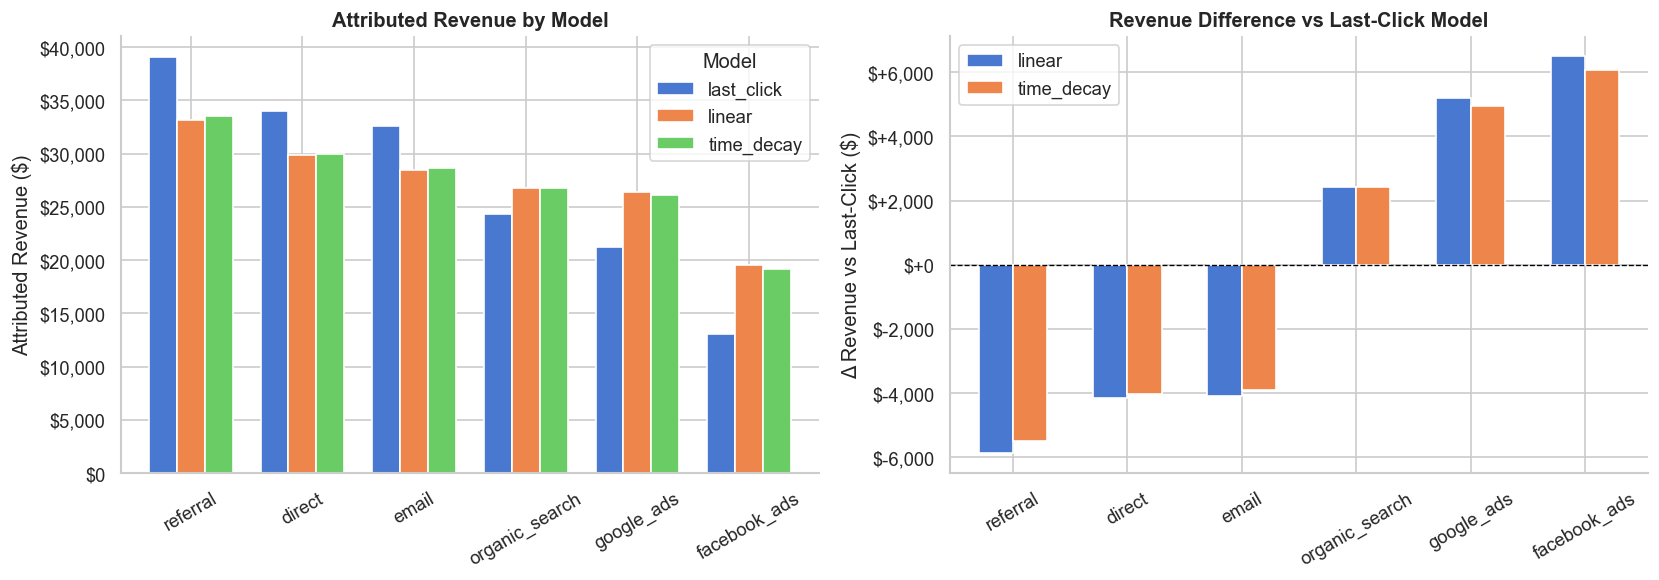

In [5]:
comparison = pd.DataFrame({
    'last_click': last_click['revenue'],
    'linear': linear['revenue'],
    'time_decay': time_decay['revenue'],
}).fillna(0).sort_values('last_click', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Revenue by model
comparison.plot(kind='bar', ax=axes[0], width=0.75)
axes[0].set_title('Attributed Revenue by Model', fontweight='bold')
axes[0].set_ylabel('Attributed Revenue ($)')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].legend(title='Model')

# Divergence: how much each channel changes vs last-click
divergence = comparison.subtract(comparison['last_click'], axis=0).drop(columns=['last_click'])
divergence.plot(kind='bar', ax=axes[1], width=0.6)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('Revenue Difference vs Last-Click Model', fontweight='bold')
axes[1].set_ylabel('Δ Revenue vs Last-Click ($)')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=30)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:+,.0f}'))

plt.tight_layout()
plt.savefig('charts/attribution_comparison.png', bbox_inches='tight')
plt.show()

## 5. ROI by Channel

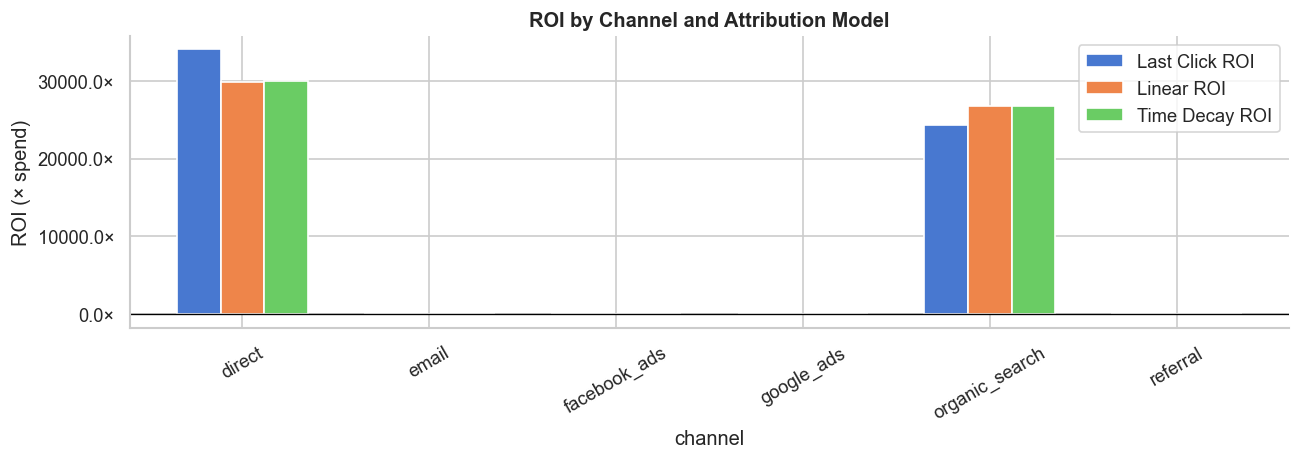

                Last Click ROI  Linear ROI  Time Decay ROI
channel                                                   
direct                34040.00    29883.27        30008.49
email                    10.34        8.92            8.98
facebook_ads             -0.44       -0.17           -0.19
google_ads               -0.39       -0.24           -0.25
organic_search        24334.00    26755.22        26756.22
referral                  1.74        1.33            1.36


In [6]:
total_cost = df.groupby('channel')['cost'].sum()

roi_df = pd.DataFrame({
    'last_click_revenue': last_click['revenue'],
    'linear_revenue': linear['revenue'],
    'time_decay_revenue': time_decay['revenue'],
    'total_cost': total_cost,
}).fillna(0)

for model in ['last_click', 'linear', 'time_decay']:
    roi_df[f'{model}_roi'] = ((roi_df[f'{model}_revenue'] - roi_df['total_cost']) / roi_df['total_cost'].replace(0, 1)).round(2)

roi_cols = [c for c in roi_df.columns if 'roi' in c]
roi_display = roi_df[roi_cols].copy()
roi_display.columns = ['Last Click ROI', 'Linear ROI', 'Time Decay ROI']

fig, ax = plt.subplots(figsize=(11, 4))
roi_display.plot(kind='bar', ax=ax, width=0.7)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('ROI by Channel and Attribution Model', fontweight='bold')
ax.set_ylabel('ROI (× spend)')
ax.tick_params(axis='x', rotation=30)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}×'))
plt.tight_layout()
plt.savefig('charts/roi_by_channel.png', bbox_inches='tight')
plt.show()

print(roi_display.to_string())

## 6. Findings & Budget Reallocation Recommendation

In [7]:
# Which channels are most over-credited under last-click?
over_credited = (comparison['last_click'] - comparison['linear']).sort_values(ascending=False)

print('=' * 65)
print('FINDINGS')
print('=' * 65)
print()
print('CHANNELS OVER-CREDITED BY LAST-CLICK (vs linear model):')
for ch, delta in over_credited.items():
    direction = 'OVER' if delta > 0 else 'UNDER'
    print(f'  {ch:<20} {direction}-credited by ${abs(delta):,.0f}')

print()
top_over = over_credited.idxmax()
top_under = over_credited.idxmin()
print(f'KEY FINDING:')
print(f'  {top_over} is the most over-credited channel under last-click.')
print(f'  {top_under} is the most under-credited — it contributes heavily to')
print(f'  the top of the funnel but rarely gets last-click credit.')
print()
print('RECOMMENDATION:')
print('  Shift 20-30% of spend from the most over-credited channel to')
print(f'  {top_under} and measure ROAS on a 90-day window using linear model.')
print('  Use time-decay as the default operational model going forward.')

FINDINGS

CHANNELS OVER-CREDITED BY LAST-CLICK (vs linear model):
  referral             OVER-credited by $5,878
  direct               OVER-credited by $4,157
  email                OVER-credited by $4,083
  organic_search       UNDER-credited by $2,421
  google_ads           UNDER-credited by $5,195
  facebook_ads         UNDER-credited by $6,501

KEY FINDING:
  referral is the most over-credited channel under last-click.
  facebook_ads is the most under-credited — it contributes heavily to
  the top of the funnel but rarely gets last-click credit.

RECOMMENDATION:
  Shift 20-30% of spend from the most over-credited channel to
  facebook_ads and measure ROAS on a 90-day window using linear model.
  Use time-decay as the default operational model going forward.
